In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ssl
# Tell Python to ignore SSL errors
ssl._create_default_https_context = ssl._create_unverified_context

In [82]:
# Now load the dataset
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [83]:
df.shape

(891, 15)

In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [85]:
df.isna().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

# Phase 1 : 

In [86]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,classification_report

In [87]:
df1 = df[['sex','class','embark_town','alone','survived']].dropna()

In [88]:
df1.head()

,sex,class,embark_town,alone,survived
0,male,Third,Southampton,False,0
1,female,First,Cherbourg,False,1
2,female,Third,Southampton,True,1
3,female,First,Southampton,False,1
4,male,Third,Southampton,True,0


In [89]:
df1.shape

(889, 5)

In [90]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   sex          889 non-null    object  
 1   class        889 non-null    category
 2   embark_town  889 non-null    object  
 3   alone        889 non-null    bool    
 4   survived     889 non-null    int64   
dtypes: bool(1), category(1), int64(1), object(2)
memory usage: 29.6+ KB


In [91]:
df['survived'].unique() # it's already encoded into 0 and 1

array([0, 1])

In [92]:
label_encoders = {}  # store the encoding obj

needed_cols = ['sex','class','embark_town','alone']      # for lable encoding

for col in needed_cols:
    le = LabelEncoder()
    df1[col] = le.fit_transform(df1[col])
    label_encoders[col] = le
    
df1.head() # now it looks like encoded

,sex,class,embark_town,alone,survived
0,1,2,2,0,0
1,0,0,0,0,1
2,0,2,2,1,1
3,0,0,2,0,1
4,1,2,2,1,0


In [93]:
X = df1.drop(columns='survived')
y = df1["survived"]

In [94]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [95]:
cnb1 = CategoricalNB()

cnb1.fit(X_train,y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


In [96]:
y_train_pred = cnb1.predict(X_train)
y_test_pred = cnb1.predict(X_test)

In [97]:
print(f"Accuracy Score Train : {accuracy_score(y_train,y_train_pred)}")
print(f"Accuracy Score Test : {accuracy_score(y_test,y_test_pred)}")

Accuracy Score Train : 0.7876230661040787
Accuracy Score Test : 0.7808988764044944


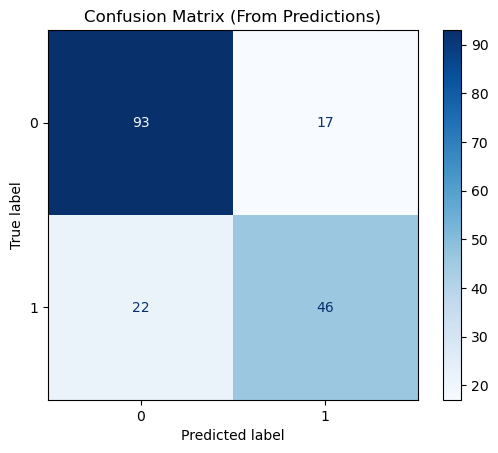

In [98]:
ConfusionMatrixDisplay.from_predictions(y_test,y_test_pred,cmap='Blues')
plt.title("Confusion Matrix (From Predictions)")
plt.show()      # total wrong predictions 22+17 = 39 from 178 

In [99]:
print(f'Classification Report : \n{classification_report(y_test,y_test_pred)}')

Classification Report : 
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       110
           1       0.73      0.68      0.70        68

    accuracy                           0.78       178
   macro avg       0.77      0.76      0.76       178
weighted avg       0.78      0.78      0.78       178



In [100]:
cv_score = cross_val_score(cnb1,X,y,cv=5,scoring='accuracy')
cv_score

array([0.66292135, 0.78651685, 0.81460674, 0.75280899, 0.78531073])

In [104]:
print(f"Cross Validation Accuracy (K fold = 5) : {cv_score.mean():.4f}")

Cross Validation Accuracy (K fold = 5) : 0.7604


#### Prediction On Sample :

In [126]:
sex_cnb = "female"
class_cnb = "First"
embark_town_cnb = "Southampton"
alone_cnb = False

In [127]:
sample = pd.DataFrame({
    "sex" : [int(label_encoders['sex'].transform([sex_cnb])[0])],
    'class' : [int(label_encoders['class'].transform([class_cnb])[0])],
    "embark_town" : [int(label_encoders['embark_town'].transform([embark_town_cnb])[0])],
    'alone' : [int(label_encoders['alone'].transform([alone_cnb])[0])]
})
sample

,sex,class,embark_town,alone
0,0,0,2,0


In [128]:
print(f"{'Survived' if cnb1.predict(sample) == 1 else 'Not Survived'}")

Survived


## Feature Engineering : 

In [ ]:
df[['sex','who'] ].head()  # these both columns represent same information i thought 

,sex,who
0,male,man
1,female,woman
2,female,woman
3,female,woman
4,male,man


In [ ]:
print(df['who'].unique())
print(df['sex'].unique())  # no i think 'child' makes it different so i'm going to keep it 
# because in our survival analysis this plays a big role wait a minute can we remove the sex and use categories like man , woman , for male child m_child, w_child or f_child

['man' 'woman' 'child']
['male' 'female']


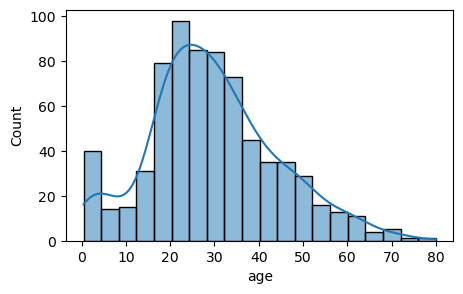

In [ ]:
plt.figure(figsize=(5,3))
sns.histplot(df["age"],kde=True)
plt.show()

In [ ]:
# Age Imputation :

# Fill NaN with the median age of the matching Pclass and Sex group
df['age'] = df['age'].fillna(df.groupby(['pclass', 'sex'])['age'].transform('median'))

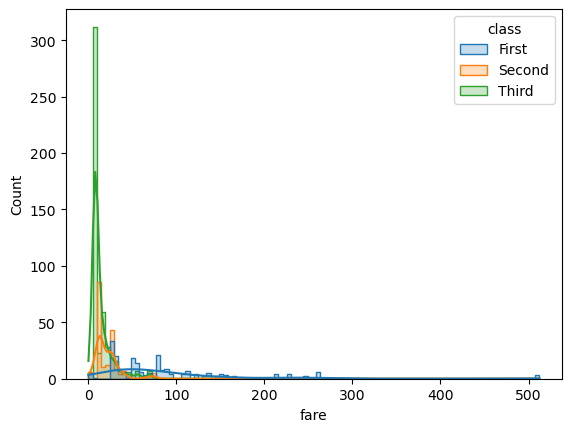

In [ ]:
sns.histplot(
    data=df,
    x='fare',
    hue='class',
    kde=True,
    element='step'
)

plt.show()